# Prediction of chances of admission of students for a education consultancy using linear regression.

- Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE orSAT, their unique problem-solving methods ensure maximum scores with minimum effort. They recentlylaunched a feature where students/learners can come to their website and check their probability of gettinginto the IVY league college. This feature estimates the chances of graduate admission from an Indianperspective.

# Business Problem

- Perform analysis to help Jamboree in understanding what factors are important in graduate admissions and how these factors are interrelated among themselves. It will also help predict one's chances of admissiongiven the rest of the variables.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [7]:
df = pd.read_csv("jamboree_Admission.csv")

In [8]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [9]:
df.shape

(500, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [11]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


## DATA CLEANING

In [13]:
df.isna().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

- There no null values

In [15]:
df.drop(columns = "Serial No.", inplace = True)

In [16]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


- column Serial No. is an unique identifier, so cannot be use full to build models let's drop it.

In [18]:
df.rename(columns = {'GRE Score':'gre_score' , 'TOEFL Score':'toefl_score' , 'University Rating':'university_rating',
                     'SOP':'sop' , 'LOR ':'lor' , 'CGPA':'cgpa', 'Research':'research' , 'Chance of Admit ':'chance_of_admit'},inplace = True)

## Univarate analysis

### GRE Score

In [21]:
df['gre_score'].describe()

count    500.000000
mean     316.472000
std       11.295148
min      290.000000
25%      308.000000
50%      317.000000
75%      325.000000
max      340.000000
Name: gre_score, dtype: float64

<Axes: xlabel='gre_score'>

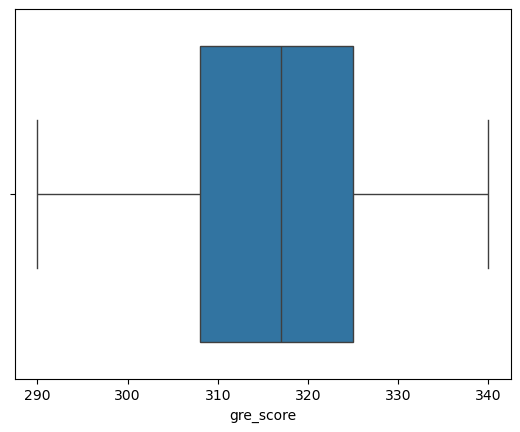

In [22]:
sns.boxplot(x = df['gre_score'])

- There are no outliers.
- Average GRE Score is 316.

### TOEFL Score

In [25]:
df['toefl_score'].describe()

count    500.000000
mean     107.192000
std        6.081868
min       92.000000
25%      103.000000
50%      107.000000
75%      112.000000
max      120.000000
Name: toefl_score, dtype: float64

<Axes: xlabel='toefl_score'>

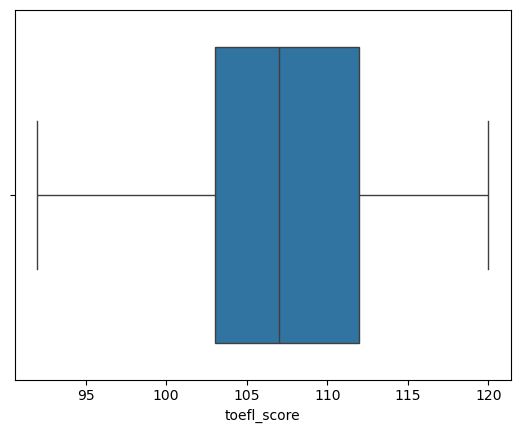

In [26]:
sns.boxplot( x = df['toefl_score'])

- There are no outliers.
- Average TOEFL Score is 107

### University Ranking

In [29]:
df['university_rating'].describe()

count    500.000000
mean       3.114000
std        1.143512
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: university_rating, dtype: float64

<Axes: xlabel='university_rating', ylabel='count'>

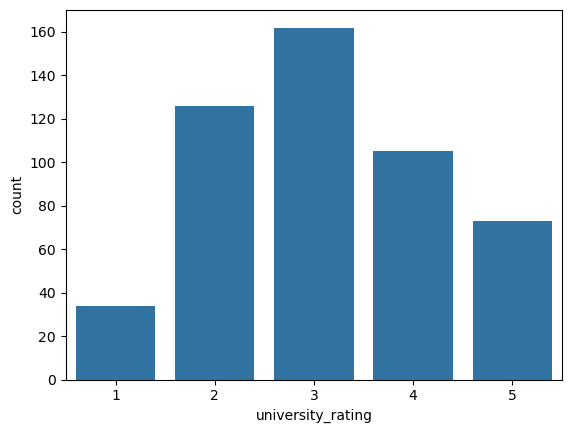

In [30]:
sns.countplot(x = df['university_rating'])

- Most people have university rating of 2 and 3.

### SOP

In [33]:
df['sop'].describe()

count    500.000000
mean       3.374000
std        0.991004
min        1.000000
25%        2.500000
50%        3.500000
75%        4.000000
max        5.000000
Name: sop, dtype: float64

In [34]:
df['sop'].value_counts()

sop
4.0    89
3.5    88
3.0    80
2.5    64
4.5    63
2.0    43
5.0    42
1.5    25
1.0     6
Name: count, dtype: int64

<Axes: xlabel='sop', ylabel='count'>

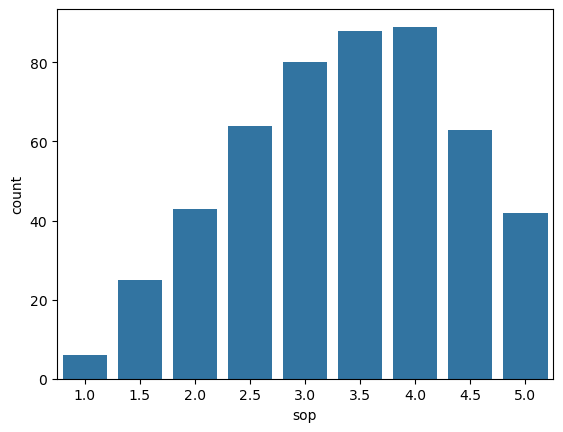

In [35]:
sns.countplot( x = df['sop'])

- Most people have statement of purpose strength between 2.5 and 4.5 out of 5.

### LOR

In [38]:
df['lor'].describe()

count    500.00000
mean       3.48400
std        0.92545
min        1.00000
25%        3.00000
50%        3.50000
75%        4.00000
max        5.00000
Name: lor, dtype: float64

In [39]:
df['lor'].value_counts()

lor
3.0    99
4.0    94
3.5    86
4.5    63
2.5    50
5.0    50
2.0    46
1.5    11
1.0     1
Name: count, dtype: int64

<Axes: xlabel='lor', ylabel='count'>

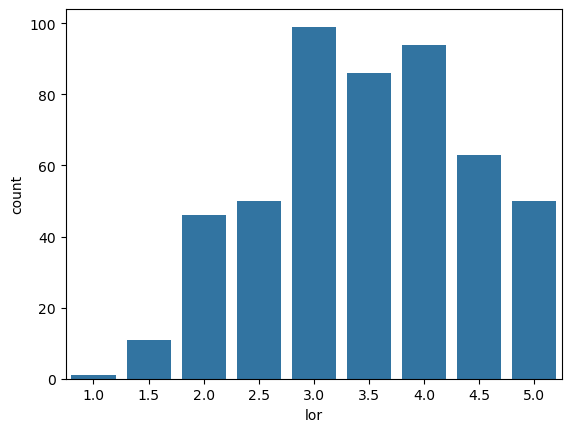

In [40]:
sns.countplot( x = df['lor'])

- Most people have letter recommendation strength between 3 and 4.5 out of 5.

### CGPA

In [43]:
df['cgpa'].describe()

count    500.000000
mean       8.576440
std        0.604813
min        6.800000
25%        8.127500
50%        8.560000
75%        9.040000
max        9.920000
Name: cgpa, dtype: float64

<Axes: xlabel='cgpa'>

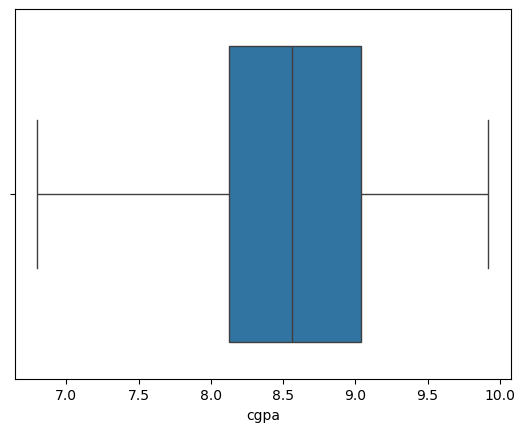

In [44]:
sns.boxplot( x = df['cgpa'])

- There are no outliers in CGPA.
- The average CGPA is 8.57.

### Research

In [47]:
df['research'].value_counts(1) * 100

research
1    56.0
0    44.0
Name: proportion, dtype: float64

<Axes: xlabel='research', ylabel='count'>

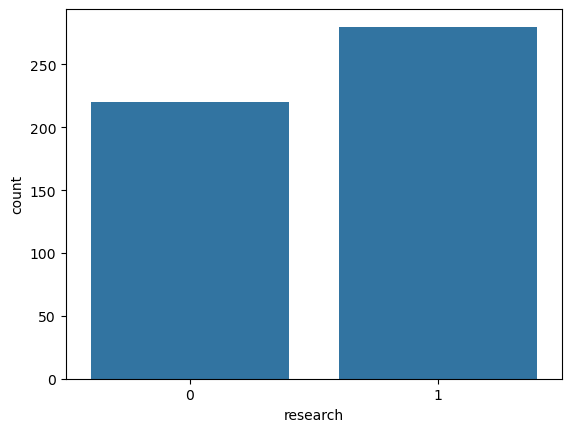

In [48]:
sns.countplot(x = df['research'])

- 56 % of students have research experience.

### Chance of admit

In [51]:
df['chance_of_admit'].describe()*100

count    50000.00000
mean        72.17400
std         14.11404
min         34.00000
25%         63.00000
50%         72.00000
75%         82.00000
max         97.00000
Name: chance_of_admit, dtype: float64

<Axes: xlabel='chance_of_admit'>

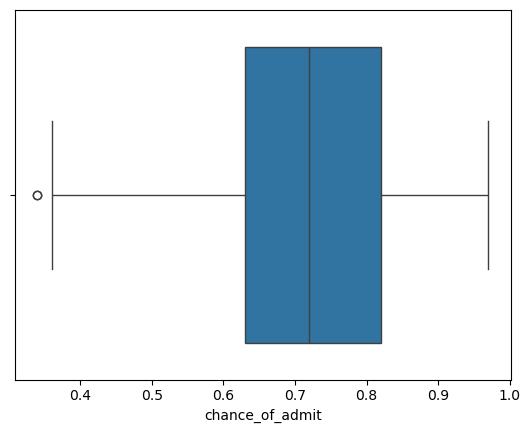

In [52]:
sns.boxplot(x = df['chance_of_admit'])

- There are no outliers in chance of admit.
- The average chance of admit is 72.17 %.

## Multivarate Analysis

### GRE SCORE VS CHANCE OF ADMIT

<Axes: xlabel='gre_score', ylabel='chance_of_admit'>

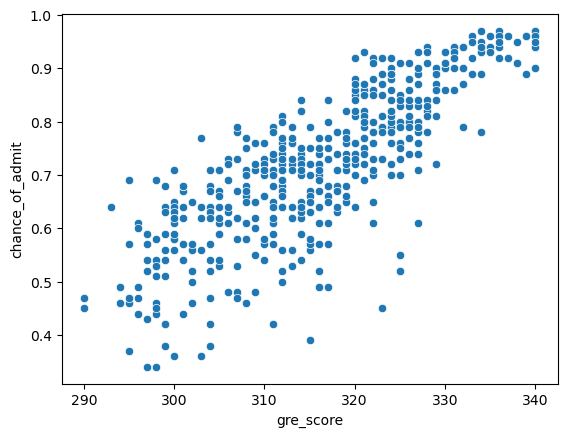

In [56]:
sns.scatterplot( x = df['gre_score'] , y = df['chance_of_admit'])

- We can infer from the graph that higher the gre score the higher the chance of admit.
- We can also see that with gre score above 320 has higher chance of admit.

### TOFEL SCORE VS CHANCE OF ADMIT

<Axes: xlabel='toefl_score', ylabel='chance_of_admit'>

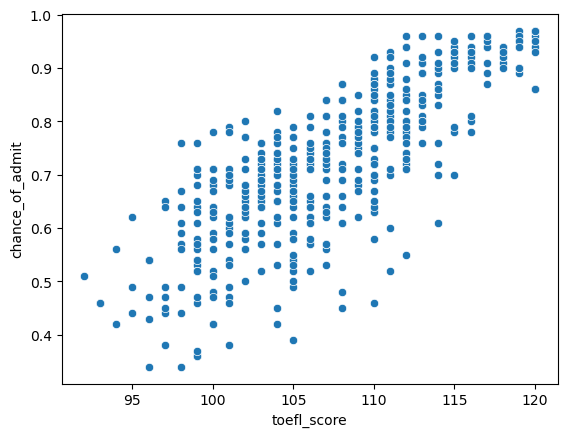

In [59]:
sns.scatterplot( x = df['toefl_score'], y = df['chance_of_admit'])

- We can infer from the graph that students with higher toefl score has higher chance of admit.
- We can also see that toefl score above 115 has higher chance of admit.

### CGPA VS CHANCE OF ADMIT

<Axes: xlabel='cgpa', ylabel='chance_of_admit'>

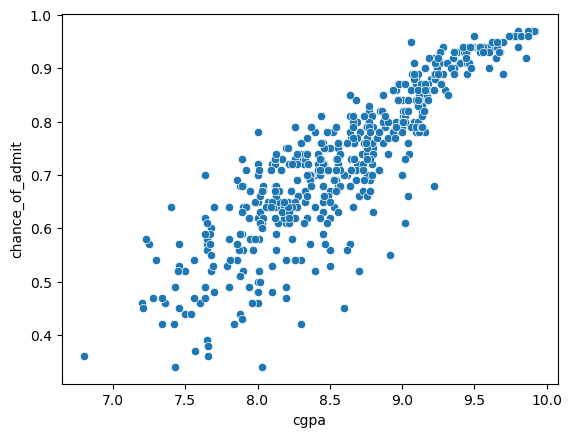

In [62]:
sns.scatterplot(x = df['cgpa'], y = df['chance_of_admit'])

- We can infer from the graph that students with higher cgpa higher chance of admit.
- We can also see that students with cgpa above 9 tend to have higher chance of admit.

### RESEARCH VS CHANCE OF ADMIT

<Axes: xlabel='research', ylabel='chance_of_admit'>

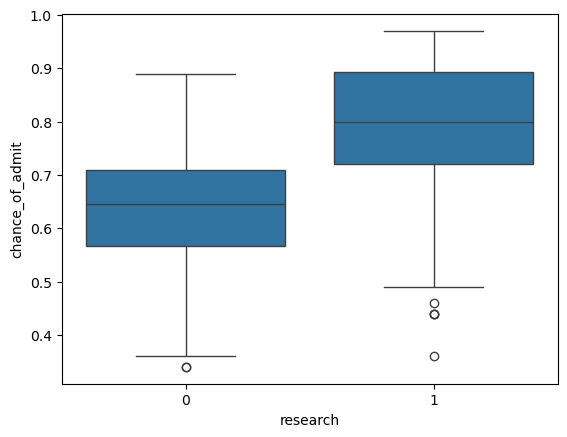

In [75]:
sns.boxplot(x = df['research'], y = df['chance_of_admit'])

- We can see that people with research experience has higher chance of admit.

### UNIVERSITY RATING VS CHANCE OF ADMIT

<Axes: xlabel='university_rating', ylabel='chance_of_admit'>

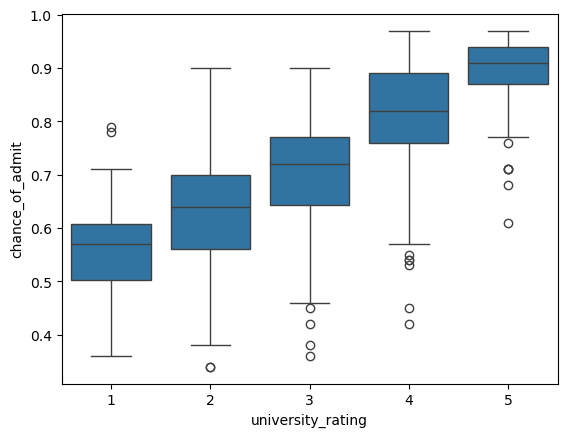

In [85]:
sns.boxplot(x = df['university_rating'], y = df['chance_of_admit'])

- We can infer that people with higher university ranking has higher chance of admit.

### SOP VS CHANCE OF ADMIT

<Axes: xlabel='sop', ylabel='chance_of_admit'>

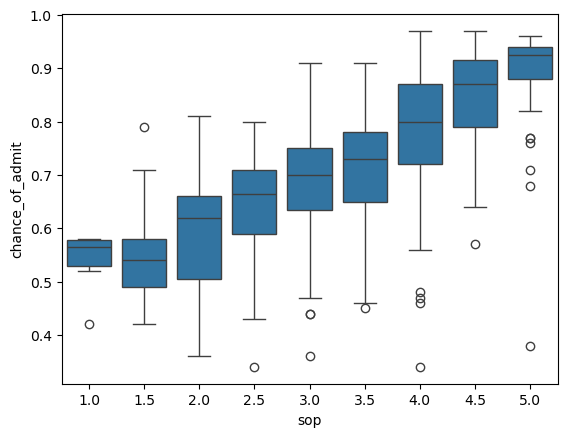

In [89]:
sns.boxplot(x = df['sop'], y = df['chance_of_admit'])

- We can see the trend that stronger sop has higher chance of admit.

### LOR VS CHANCE OF ADMIT

<Axes: xlabel='lor', ylabel='chance_of_admit'>

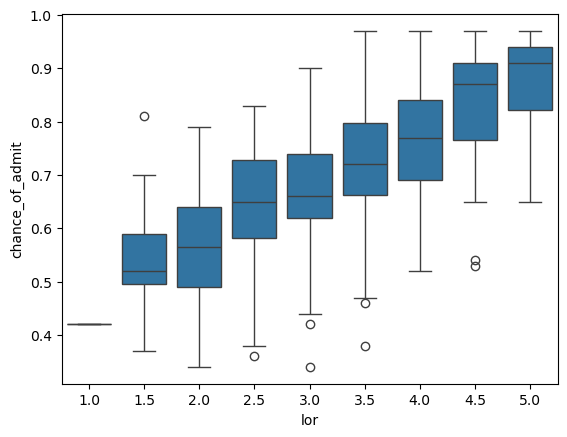

In [92]:
sns.boxplot(x = df['lor'], y = df['chance_of_admit'])

- We can see the trend that people with stronger lor trend to have higher chance of admit.

### CORRELATION BETWEEN VARIABLES

<Axes: >

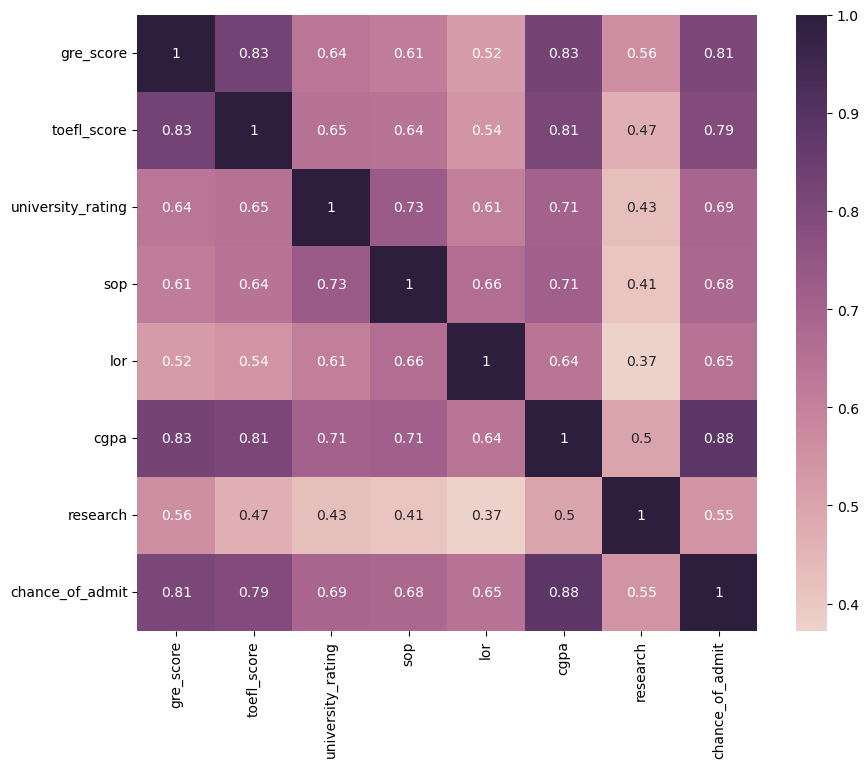

In [95]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),cmap = sns.cubehelix_palette(as_cmap=True),annot=True)

### CORRELATION OF VARIABLES W.R.T CHANCE OF ADMIT

- GRE Score - higher correlation(0.81)
- TOEFL Score - higher correlation(0.79)
- University Ranking - good correlation(0.69)
- SOP - good correlation(0.68)
- LOR - good correlation(0.65)
- CGPA - higher coorelation(0.88)
- Research - medium correlation(0.55)

### OTHER CORRELATIONS

- CGPA and GRE Score(0.83)
- CGPA and TOEFL Score(0.81)
- TOEFL Score and GRE Score(0.83)

## DATA PREPROCESSING

## DUPLICATE VALUE CHECK

In [100]:
duplicates = df[df.duplicated()]
duplicates

,gre_score,toefl_score,university_rating,sop,lor,cgpa,research,chance_of_admit


- There are no duplicates.

## MISSING VALUE CHECK

In [104]:
df.isnull().sum()

gre_score            0
toefl_score          0
university_rating    0
sop                  0
lor                  0
cgpa                 0
research             0
chance_of_admit      0
dtype: int64

- There are no null values.

## OUTLIER TREATMENT

- As already checked in EDA there is no need for outlier treatment.

## MODEL BUILDING

- The TARGET VARIABLE is CHANCE OF ADMIT
- Since the target variable is numerical and continous we can create linear regression model on it.

In [127]:
from sklearn.model_selection import train_test_split

X = df.drop('chance_of_admit', axis=1)
y = df['chance_of_admit']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [128]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [129]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

### METRICS

In [131]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = lr.predict(X_test)


print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.8188432567829629
MAE: 0.04272265427705366
RMSE: 0.0608658804157831


### ACTUAL VS PREDICTION

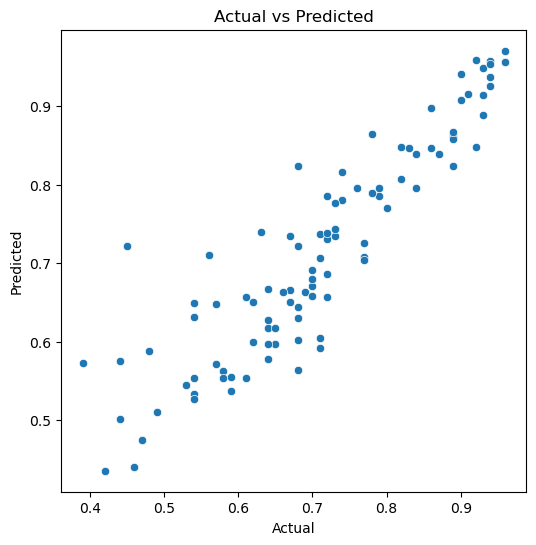

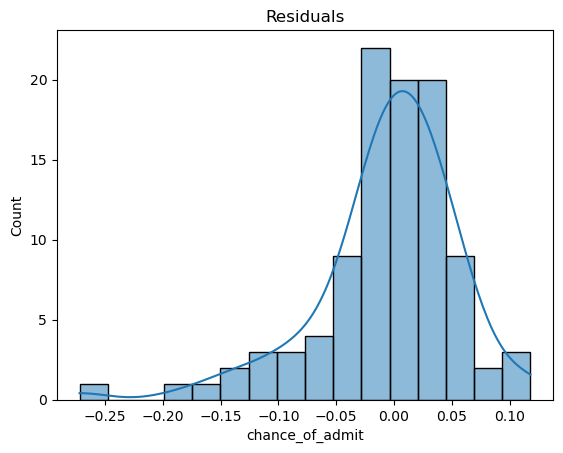

In [137]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

residuals = y_test - y_pred
sns.histplot(residuals, kde = True)
plt.title('Residuals')
plt.show()

### WEIGHTS

In [139]:
w0 = lr.intercept_
w1 = lr.coef_
print(f'w0:{w0}')
print(f'w1:{w1}')

w0:0.7241749999999999
w1:[0.02667052 0.01822633 0.00293995 0.001788   0.0158655  0.06758106
 0.01194049]


In [142]:
columns = list(df.columns)
columns = columns[:-1]
columns

['gre_score',
 'toefl_score',
 'university_rating',
 'sop',
 'lor',
 'cgpa',
 'research']

In [144]:
weights = pd.DataFrame(list(zip(columns, w1)))

In [146]:
weights

,0,1
0,gre_score,0.026671
1,toefl_score,0.018226
2,university_rating,0.002940
3,sop,0.001788
4,lor,0.015866
5,cgpa,0.067581
6,research,0.011940


### MEAN OF RESIDUAL

In [148]:
residual = (y_test - y_pred)

In [150]:
np.mean(residual)

-0.005453623717661271

- Mean of residual is close to zero.

### NORMALITY OF RESIDUALS

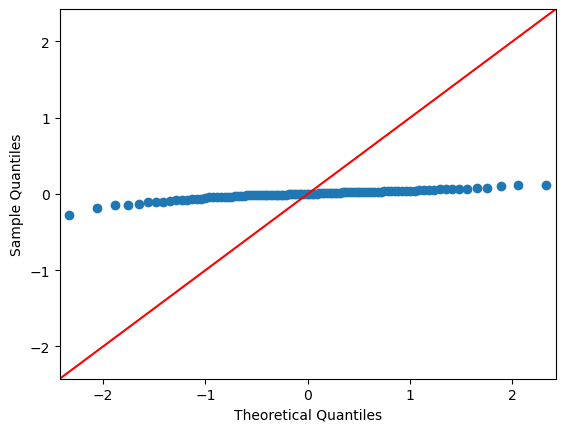

In [155]:
fig = sm.qqplot(residual, line = '45')
plt.show()

- Normality of residual is good, but improvement can be done.

### CHECK FOR HOMOSCEDACITY USING BARTLETT

### GRE SCORE

In [160]:
from scipy.stats import bartlett

In [162]:
test0 = bartlett(X_train[0], residual)
test0

BartlettResult(statistic=74.96883221936486, pvalue=4.782039565933959e-18)

- For gre score Pvalue is greater 0.05 hence homoscedaticity(i.e null hypothesis) accepted.

### TOEFL SCORE

In [166]:
test1 = bartlett(X_train[1], residual)
test1

BartlettResult(statistic=221.28922272532407, pvalue=4.7334183566974945e-50)

- For toefl score Pvalue is greater 0.05 hence homoscedaticity(i.e null hypothesis) accepted.

### UNIVERSITY RATING

In [170]:
test2 = bartlett(X_train[2],residual)
test2

BartlettResult(statistic=143.86405747764317, pvalue=3.804632523784419e-33)

- For university ranking Pvalue is greater 0.05 hence homoscedaticity(i.e null hypothesis) accepted

### SOP

In [173]:
test3 = bartlett(X_train[3],residual)
test3

BartlettResult(statistic=159.14497319415597, pvalue=1.7396602122504842e-36)

- For sop Pvalue is greater 0.05 hence homoscedaticity(i.e null hypothesis) accepted.

### LOR

In [177]:
test4 = bartlett(X_train[4],residual)
test4

BartlettResult(statistic=174.06427763293635, pvalue=9.584013889228904e-40)

- For lor Pvalue is greater 0.05 hence homoscedaticity(i.e null hypothesis) accepted.

### CGPA

In [182]:
test5 = bartlett(X_train[5],residual)
test5

BartlettResult(statistic=183.79324948602215, pvalue=7.198576286722528e-42)

- For cgpa Pvalue is less 0.05 hence homoscedaticity(i.e null hypothesis) rejected.

### RESEARCH

In [186]:
test6 = bartlett(X_train[6],residual)
test6

BartlettResult(statistic=161.7016220839267, pvalue=4.807024252940217e-37)

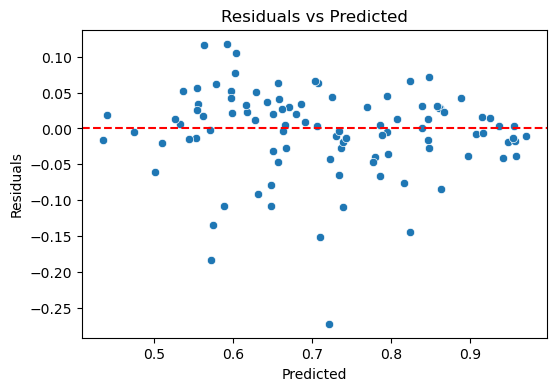

In [188]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

- Residuals show random scatter around zero, indicating a reasonably good fit. Slight heteroscedasticity is observed, but linear regression assumptions are mostly satisfied.

In [193]:
df['chance_of_admit_log'] = np.log(df['chance_of_admit'])

In [197]:
X = df.drop(['chance_of_admit','chance_of_admit_log'], axis=1)
y = df['chance_of_admit_log']

X_train_,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [199]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [201]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [203]:
y_pred = lr.predict(X_test)


print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.7674048489531231
MAE: 0.0706162978617221
RMSE: 0.10203161991992594


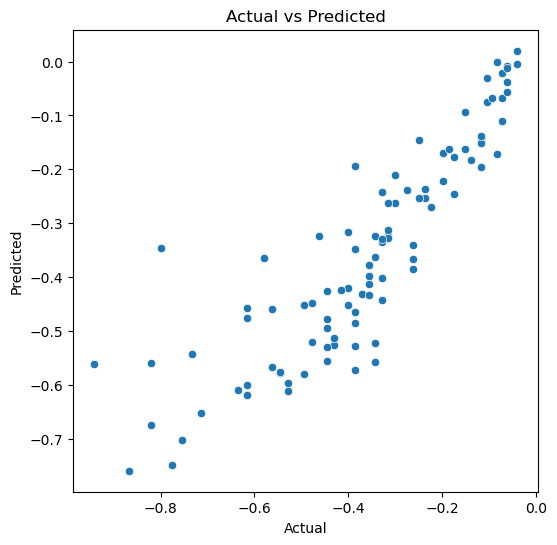

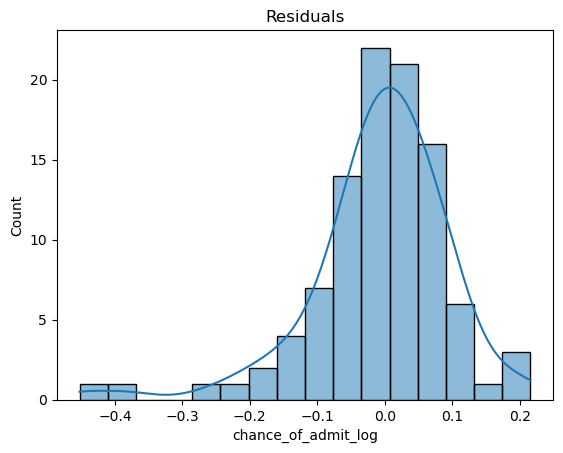

In [205]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

residuals = y_test - y_pred
sns.histplot(residuals, kde = True)
plt.title('Residuals')
plt.show()

In [209]:
df_resid = pd.DataFrame({'predicted': y_pred, 'residuals': residuals})
df_resid['group'] = pd.qcut(df_resid['predicted'], q=4, duplicates='drop')
groups = [group['residuals'].values for name, group in df_resid.groupby('group')]

# Bartlett’s test
stat, p = bartlett(*groups)
print("Bartlett’s test p-value (after log transform):", p)

Bartlett’s test p-value (after log transform): 9.748079852911468e-06


C:\Users\Ragav Hari\AppData\Local\Temp\ipykernel_11960\3640863693.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['residuals'].values for name, group in df_resid.groupby('group')]


- Bartlett’s test remained significant (p < 0.05) even after log transformation, indicating persistent heteroscedasticity. Therefore, I will explore tree-based models, which are robust to this violation

## RANDOM FORREST REGRESSOR

In [215]:
from sklearn.ensemble import RandomForestRegressor

In [219]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)

In [221]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [223]:
y_pred_rf = rf.predict(X_test)

In [225]:
print("Random Forest R² Score:", r2_score(y_test, y_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R² Score: 0.7382062418858667
Random Forest MAE: 0.06868488925020876
Random Forest RMSE: 0.10824655841006303


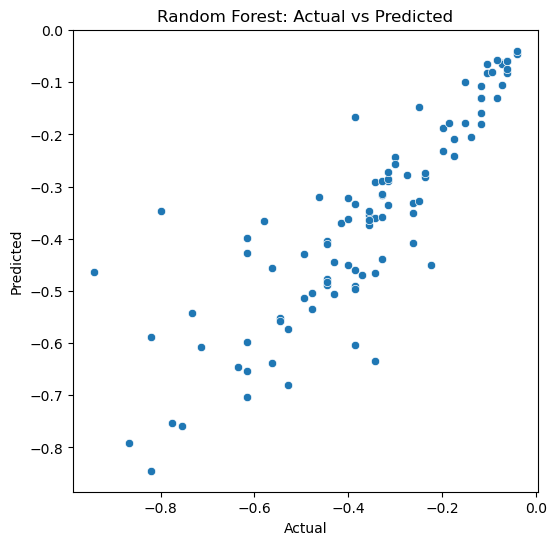

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

R² ~ 0.74

Slightly lower than your linear regression R² (~0.77).

MAE & RMSE

Similar to linear regression results.

Indicates predictive performance is comparable.

In [234]:
import joblib

In [258]:
joblib.dump(rf, 'jamboree_rf_model.pkl')
joblib.dump(scaler, 'jamboree_scaler.pkl')

['jamboree_scaler.pkl']